In [44]:
import mlflow
import mlflow.sklearn
mlflow.set_tracking_uri("sqlite://///Users/rishabh/Desktop/PatrollQ/mlflow.db")

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.metrics import silhouette_score

In [3]:
df=pd.read_csv('../data/cleaned_crime_records.csv')

In [4]:
df= df.sample(n=150000, random_state=42)

In [41]:
df.columns

Index(['ID', 'Date', 'Primary Type', 'Description', 'Location Description',
       'Arrest', 'Domestic', 'District', 'Ward', 'Community Area', 'Latitude',
       'Longitude', 'hour', 'day', 'month', 'year', 'weekend', 'cluster'],
      dtype='str')

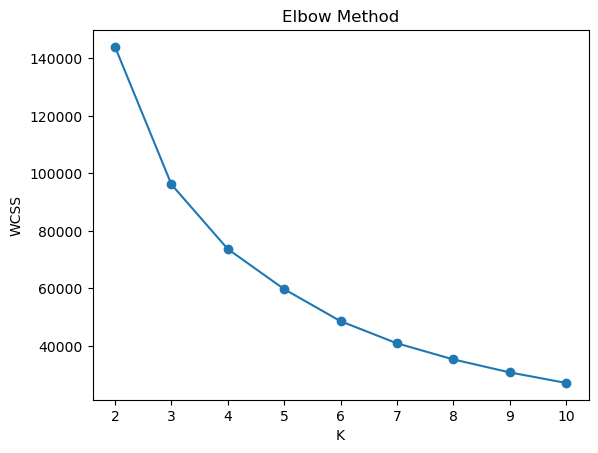

In [5]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

X = df[['Latitude','Longitude']]
X = X.astype('float32')

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

wcss = []

for k in range(2,11):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

plt.plot(range(2,11), wcss, marker='o')
plt.xlabel("K")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()


In [7]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

X = df[['Latitude','Longitude']]
X = X.astype('float32')

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# mlflow.set_experiment("PatrollQ")

k = 7

# with mlflow.start_run(run_name="Kmeans CLustering"):


kmeans = KMeans(n_clusters=k, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)
    # # sil_score = silhouette_score(X_scaled, df['cluster'])
    # mlflow.log_param("algorithm", "KMeans")
    # mlflow.log_param("n_clusters", k)
    # mlflow.log_metric("silhouette_score", sil_score)
    # mlflow.sklearn.log_model(kmeans, "kmeans_model")
# print("Done logging")

In [13]:
import mlflow
# mlflow.set_tracking_uri("file:./mlruns")
print(mlflow.get_tracking_uri())

sqlite://///Users/rishabh/Desktop/PatrollQ/mlflow.db


In [ ]:
mlflow.set_tracking_uri("sqlite://///Users/rishabh/Desktop/PatrollQ/mlflow.db")

In [48]:
X.dtypes

Latitude     float32
Longitude    float32
dtype: object

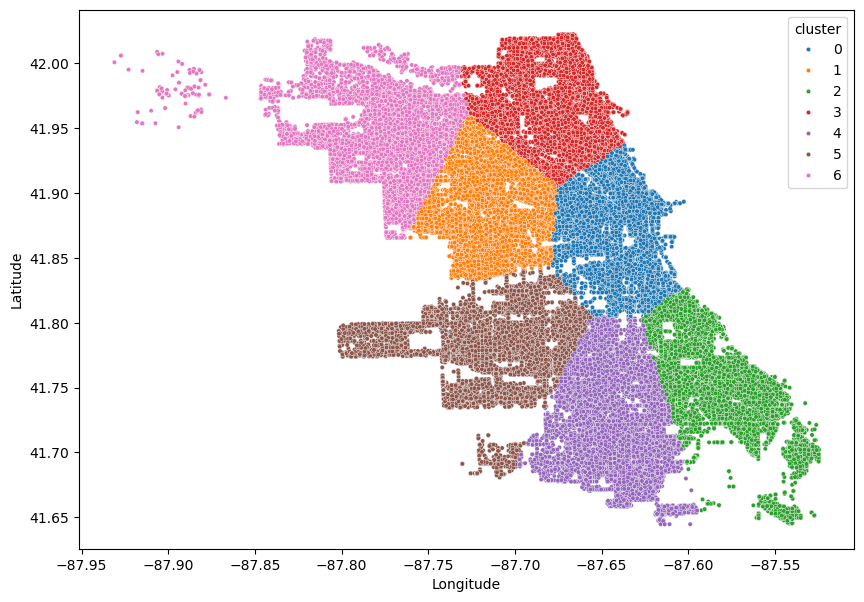

In [8]:
plt.figure(figsize=(10,7))
sns.scatterplot(
x=df['Longitude'],
y=df['Latitude'],
hue=df['cluster'],
palette='tab10',
s=10
)
plt.show()

In [ ]:
# from sklearn.metrics import silhouette_score

# score = silhouette_score(X_scaled, df['cluster'])
# print(score)

0.3934597969055176


In [9]:
df['cluster'].value_counts()

cluster
0    29656
1    25233
2    23746
4    22543
3    19700
5    14847
6    14275
Name: count, dtype: int64

In [10]:
cluster_sizes = df['cluster'].value_counts().reset_index()
cluster_sizes.columns = ['cluster', 'size']

df = df.merge(cluster_sizes, on='cluster')


In [11]:
df['cluster'].value_counts()

cluster
0    29656
1    25233
2    23746
4    22543
3    19700
5    14847
6    14275
Name: count, dtype: int64

In [73]:
df.columns

Index(['ID', 'Date', 'Primary Type', 'Description', 'Location Description',
       'Arrest', 'Domestic', 'District', 'Ward', 'Community Area', 'Latitude',
       'Longitude', 'hour', 'day', 'month', 'year', 'weekend', 'cluster',
       'size'],
      dtype='str')

In [84]:
df[(df['cluster'] == 0)]['District'].value_counts()

District
11    26771
10    19605
14    12096
12    10205
25     7656
15     3937
17     2279
Name: count, dtype: int64

In [25]:
df[(df['cluster'] == 4)]['District'].value_counts()

District
25    23409
16    17130
15    16121
17     5658
11     1441
31       19
Name: count, dtype: int64

In [12]:
ls_high_crime=df[(df['cluster'] == 3)]['District'].value_counts().index
ls_high_crime

Index([25, 16, 15, 17, 11, 31], dtype='int64', name='District')

In [13]:
df[(df['cluster'] == 3)][''].value_counts()

KeyError: ''

In [ ]:
df[(df['cluster'] == 0)]['District'].value_counts()

In [12]:
df.tail()

,ID,Date,Primary Type,Description,Location Description,Arrest,Domestic,District,Ward,Community Area,Latitude,Longitude,hour,day,month,year,weekend,cluster,size
149995,13499087,2024-06-17 23:53:00,ROBBERY,STRONG ARM - NO WEAPON,STREET,False,False,25,37.0,19.0,41.917017,-87.760852,23,Monday,6,2024,False,6,14275
149996,13916168,2025-07-27 00:30:00,THEFT,POCKET-PICKING,BAR OR TAVERN,False,False,18,42.0,8.0,41.893542,-87.629702,0,Sunday,7,2025,True,0,29656
149997,13398376,2024-03-13 22:00:00,THEFT,OVER $500,STREET,False,False,12,27.0,24.0,41.890117,-87.645157,22,Wednesday,3,2024,False,0,29656
149998,14103229,2026-01-21 09:00:00,THEFT,$500 AND UNDER,PARKING LOT / GARAGE (NON RESIDENTIAL),False,False,12,27.0,28.0,41.874141,-87.670003,9,Wednesday,1,2026,False,0,29656
149999,14015266,2025-10-31 20:18:00,WEAPONS VIOLATION,RECKLESS FIREARM DISCHARGE,STREET,False,False,16,31.0,15.0,41.941699,-87.754335,20,Friday,10,2025,False,6,14275


In [13]:
import plotly.express as px
import plotly.io as pio

# pio.renderers.default = "notebook_connected"
pio.renderers.default = "browser"

fig = px.scatter_mapbox(
    df,
    lat="Latitude",
    lon="Longitude",
    color="cluster",
    hover_name="cluster",
    hover_data={
        "Latitude": True,
        "Longitude": True
    },
    zoom=10,
    height=700,
    title="Crime Hotspot Clusters (DBSCAN)"
)
fig.update_layout(
    mapbox_style="open-street-map",
    margin={"r":0, "t":50, "l":0, "b":0}
)

fig.show()

/var/folders/33/6j7x5yjn4vs9rpp5_xx32x740000gn/T/ipykernel_16382/2330931276.py:7: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.scatter_mapbox(


In [ ]:
%pip install --upgrade pip setuptools wheel


In [ ]:
%pip install shapely geopandas

In [14]:
from shapely.geometry import MultiPoint
import geopandas as gpd

polygons = []

for cluster_id, group in df[df['cluster'] != -1].groupby('cluster'):
    points = list(zip(group['Longitude'], group['Latitude']))
    
    if len(points) > 2:
        hull = MultiPoint(points).convex_hull
        polygons.append({
            'cluster': cluster_id,
            'size': len(points),
            'geometry': hull
        })

gdf = gpd.GeoDataFrame(polygons, crs="EPSG:4326")


In [17]:
geojson = gdf.__geo_interface__

In [ ]:
%pip install nbformat ipywidgets


In [ ]:
%pip install notebook

In [15]:
gdf.head()

,cluster,size,geometry
0,0,29656,"POLYGON ((-87.63325 41.80458, -87.65517 41.805..."
1,1,25233,"POLYGON ((-87.72213 41.83332, -87.73659 41.834..."
2,2,23746,"POLYGON ((-87.5416 41.64512, -87.59243 41.6553..."
3,3,19700,"POLYGON ((-87.67611 41.90603, -87.68411 41.914..."
4,4,22543,"POLYGON ((-87.61588 41.64459, -87.64528 41.658..."


In [18]:
import plotly.express as px
import plotly.io as pio

# pio.renderers.default = "notebook_connected"
pio.renderers.default = "browser"

fig = px.choropleth_mapbox(
    gdf,
    geojson=geojson,
    locations=gdf.index,
    color='size',
    color_continuous_scale=["green", "yellow", "red"],  # 🔥 your requirement
    mapbox_style="open-street-map",
    center={
        "lat": df["Latitude"].mean(),
        "lon": df["Longitude"].mean()
    },
    zoom=9,
    opacity=0.5
)

fig.show()


/var/folders/33/6j7x5yjn4vs9rpp5_xx32x740000gn/T/ipykernel_16382/3346671167.py:7: DeprecationWarning: *choropleth_mapbox* is deprecated! Use *choropleth_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.choropleth_mapbox(
